# 18.6 教師與學生的 token 對得上嗎？


教師與學生都輸出兩個機率，看形狀相同就能直接比較嗎？若教師詞表是 `[貓,狗]`，學生卻是 `[狗,貓]`，第0欄代表的候選不同。把兩邊第0欄硬對上，會教學生將教師的貓機率配給狗。這不是學生尚未學好，而是我們把答案名稱弄錯。我們希望兩邊都把貓的80%對上貓；[同樣大小的分布](https://birdhackor.github.io/tiny-perceptron-vlm/18.4.html)還需要候選身份一致，不能只看ID數字。

教師比例 `[0.8,0.2]`，學生比例 `[0.2,0.8]`，看數值似乎差很多；但兩者都對貓給80%、狗給20%，其實語意完全相同。如果只是詞表順序交換，可以先把學生欄位重排成教師順序，再比較。若兩者切分粒度也不同，例如教師用一個「小貓」token、學生用「小」「貓」兩個，就不再是簡單交換欄位能解決。

圖上先列出兩邊自己的ID對應，下面按「貓、狗」身份配對。教師ID0的貓要對學生ID1；教師ID1的狗要對學生ID0。因此取學生欄的順序是 `[1,0]`，才得到教師順序下的 `[0.8,0.2]`。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

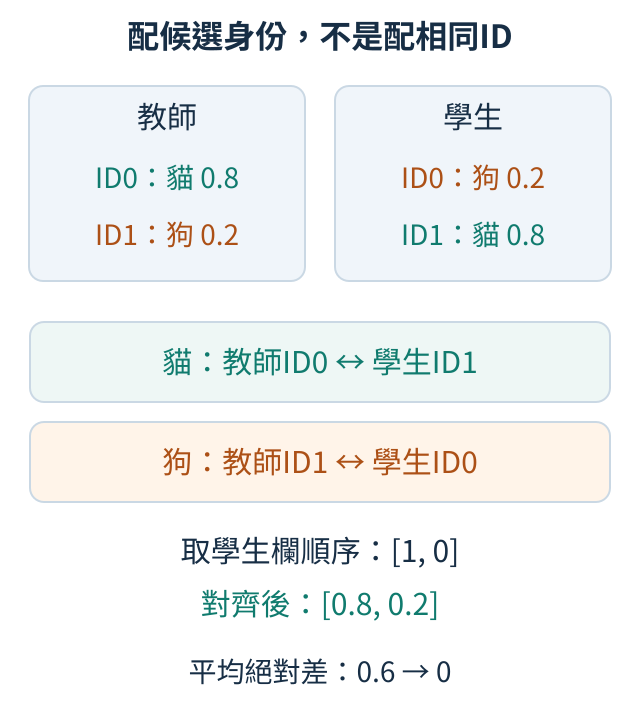

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-18-vocab-alignment.svg")))

In [3]:
import torch

teacher_vocab = ["貓", "狗"]
student_vocab = ["狗", "貓"]
p = torch.tensor([0.8, 0.2])
q = torch.tensor([0.2, 0.8])
order = [student_vocab.index(token) for token in teacher_vocab]
reordered = q[order]
print("重排索引", order)
print("錯配MAE", round((p - q).abs().mean().item(), 4))
print("對齊後", reordered.tolist(), "MAE", round((p - reordered).abs().mean().item(), 4))

重排索引 [1, 0]
錯配MAE 0.6
對齊後 [0.800000011920929, 0.20000000298023224] MAE 0.0


`index(token)`尋找該詞在學生詞表的欄號，依教師詞表順序建立order，應為 `[1,0]`。`q[order]`沿候選軸取欄。MAE是mean absolute error（平均絕對差）：逐欄相減後，`.abs()`取絕對值、`.mean()`求平均、`.item()`取出單一Python數字。錯配時是`(|0.8-0.2|+|0.2-0.8|)/2=0.6`，對齊後每欄相同，因此為0。這個MAE只作配對檢查，不是正式[蒸餾KL](https://birdhackor.github.io/tiny-perceptron-vlm/18.8.html)；只要同一欄語義錯了，後續任何逐欄誤差公式都會被誤導。

此外雙方要在同一前文、同一待預測位置比較。教師已經讀到「小貓追」，學生只讀到「小貓」，即使詞表相同，分布也在回答不同問題。special tokens（特殊符號）如EOS與角色標記，也要有相同身份和對齊規則；EOS表示文字結束，角色標記辨認說話者，並不是普通字詞。詞表數量一致只是必要條件之一，不是充分保證。

練習只把student_vocab改成 `[貓,狗]`，q也同步改成 `[0.8,0.2]`。先預測order為 `[0,1]`，直接比較和重排比較都為0，再執行核對。若只改詞表不改q，你就給同一組數字換了意義，不能稱為完成對齊。

<details>
<summary>選讀：來源、量測條件與原始實報</summary>

本專案的白盒訓練入口固定共享ByteTokenizer：它是把文字轉成ID的共用工具，雙方採同一套文字單位與特殊符號ID約定，讓各ID與位置更容易一致。byte切分方式可到[6.7](https://birdhackor.github.io/tiny-perceptron-vlm/6.7.html)再讀，本節只需要知道雙方共用轉換規則。使用不同切詞器的白盒方法需要額外設計語義與位置映射，本節不假裝交換就解決；[黑盒文字蒸餾](https://birdhackor.github.io/tiny-perceptron-vlm/18.3.html)則可先拿文字，再由學生切分，避免直接對兩份詞表逐欄比較。

正式寬64教師與寬16／32學生都用相同264-ID byte詞表，包含相同角色與EOS約定。CE+KL支線以各位置的`labels != -100`挑出回答分數，教師快取按同一筆題目、同一標準回答前文排好，再核對有效行數後計算；問題和PAD不直接算KL。教師硬回答支線則單獨保存自由生成ID，沒有拿其不同前文逐行硬配這份白盒快取。

</details>
